# Detecção de Objetos com YOLOS-Small (Hugging Face)

Neste notebook, utilizaremos o modelo **YOLOS-Small** (`hustvl/yolos-small`) do Hugging Face para realizar a detecção de objetos nas imagens contidas na pasta `imagens/`.

In [ ]:
# Instalação de dependências caso necessário
# %pip install transformers timm matplotlib

In [1]:
import os
import torch
import matplotlib.pyplot as plt 
import matplotlib.patches as patches
from PIL import Image
from transformers import YolosImageProcessor, YolosForObjectDetection

# 1. Configuração do Dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

# 2. Carregando o Modelo e o Processador de Imagem
model_name = "hustvl/yolos-small"
processor = YolosImageProcessor.from_pretrained(model_name)
model = YolosForObjectDetection.from_pretrained(model_name).to(device)
model.eval()

print(f"Modelo {model_name} carregado com sucesso!")

Usando dispositivo: cpu


preprocessor_config.json:   0%|          | 0.00/292 [00:00<?, ?B/s]

c:\Users\Murilo\Documents\arquivos_programacao\NLW\projeto 2\.venv\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Murilo\.cache\huggingface\hub\models--hustvl--yolos-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/123M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

Modelo hustvl/yolos-small carregado com sucesso!


In [2]:
# 3. Função auxiliar para visualizar os resultados
def plot_results(image, results):
    plt.figure(figsize=(16, 10))
    plt.imshow(image)
    ax = plt.gca()
    
    colors = plt.cm.hsv(torch.linspace(0, 1, 100)).tolist()
    
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        # box format: [xmin, ymin, xmax, ymax]
        xmin, ymin, xmax, ymax = box.tolist()
        
        # Adicionar retângulo
        rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin, 
                                 linewidth=2, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        
        # Adicionar texto do label
        label_text = f"{model.config.id2label[label.item()]}: {score:.2f}"
        ax.text(xmin, ymin, label_text, fontsize=12, bbox=dict(facecolor='yellow', alpha=0.5))
    
    plt.axis('off')
    plt.show()


Processando: bird.jpeg - 1 objetos detectados.


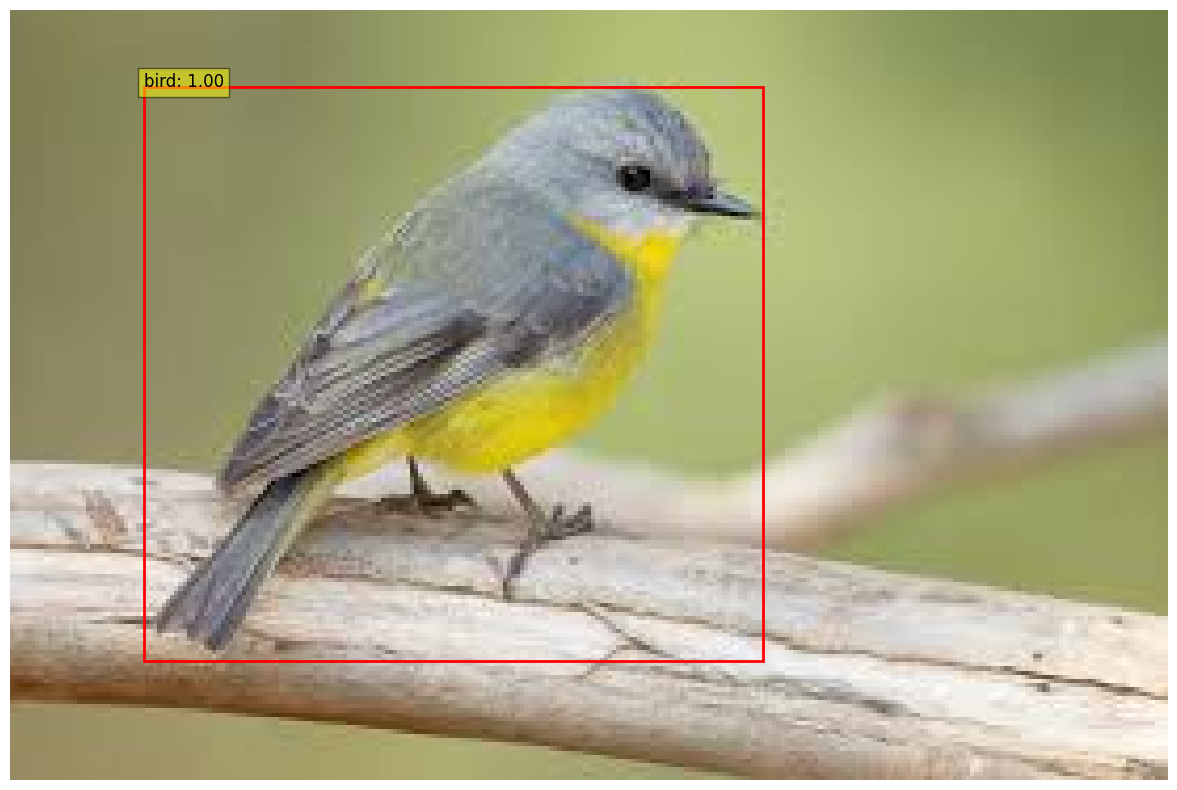


Processando: kitchen.jpeg - 3 objetos detectados.


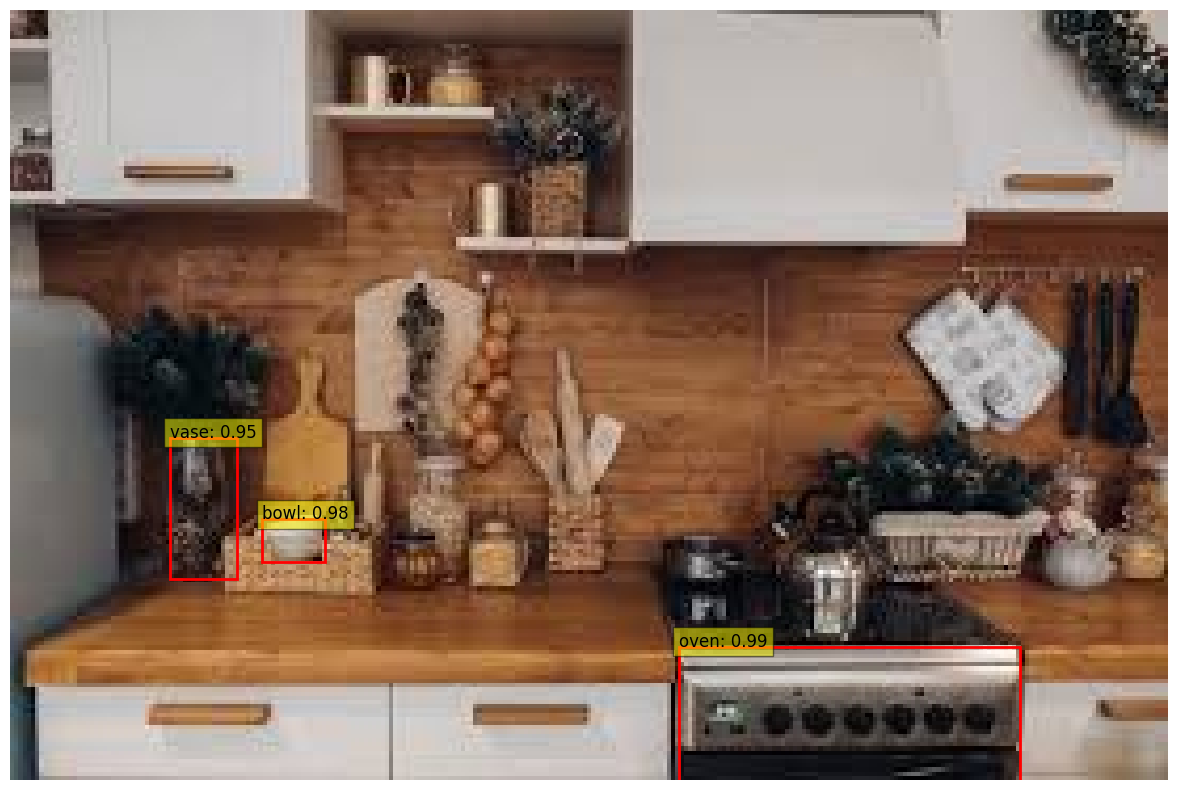


Processando: pizza.jpeg - 4 objetos detectados.


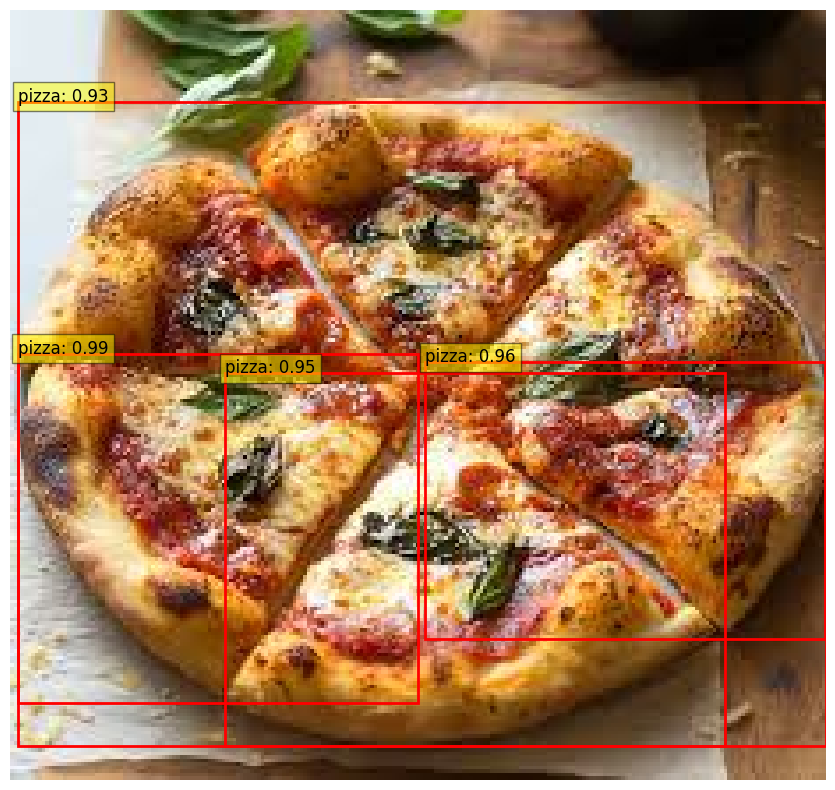

In [3]:
# 4. Processando as imagens da pasta 'imagens'
pasta_imagens = 'imagens'
formatos_suportados = ('.png', '.jpg', '.jpeg', '.webp')
arquivos = [f for f in os.listdir(pasta_imagens) if f.lower().endswith(formatos_suportados)]

if not arquivos:
    print(f"Nenhum arquivo de imagem encontrado em {pasta_imagens}")
else:
    for arq in arquivos:
        caminho = os.path.join(pasta_imagens, arq)
        image = Image.open(caminho).convert("RGB")
        
        # Preparar a imagem para o modelo
        inputs = processor(images=image, return_tensors="pt").to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
        
        # Pós-processamento para obter bounding boxes e scores
        # O modelo YOLOS usa o tamanho original da imagem para redimensionar as caixas
        target_sizes = torch.tensor([image.size[::-1]]).to(device)
        results = processor.post_process_object_detection(outputs, threshold=0.9, target_sizes=target_sizes)[0]
        
        print(f"\nProcessando: {arq} - {len(results['labels'])} objetos detectados.")
        
        if len(results['labels']) > 0:
            plot_results(image, results)
        else:
            plt.figure(figsize=(10, 6))
            plt.imshow(image)
            plt.title(f"{arq}: Nenhum objeto detectado acima do threshold.")
            plt.axis('off')
            plt.show()